SECTION 1: DATASET UNDERSTANDING
(649, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]
school        0
sex           0
age          

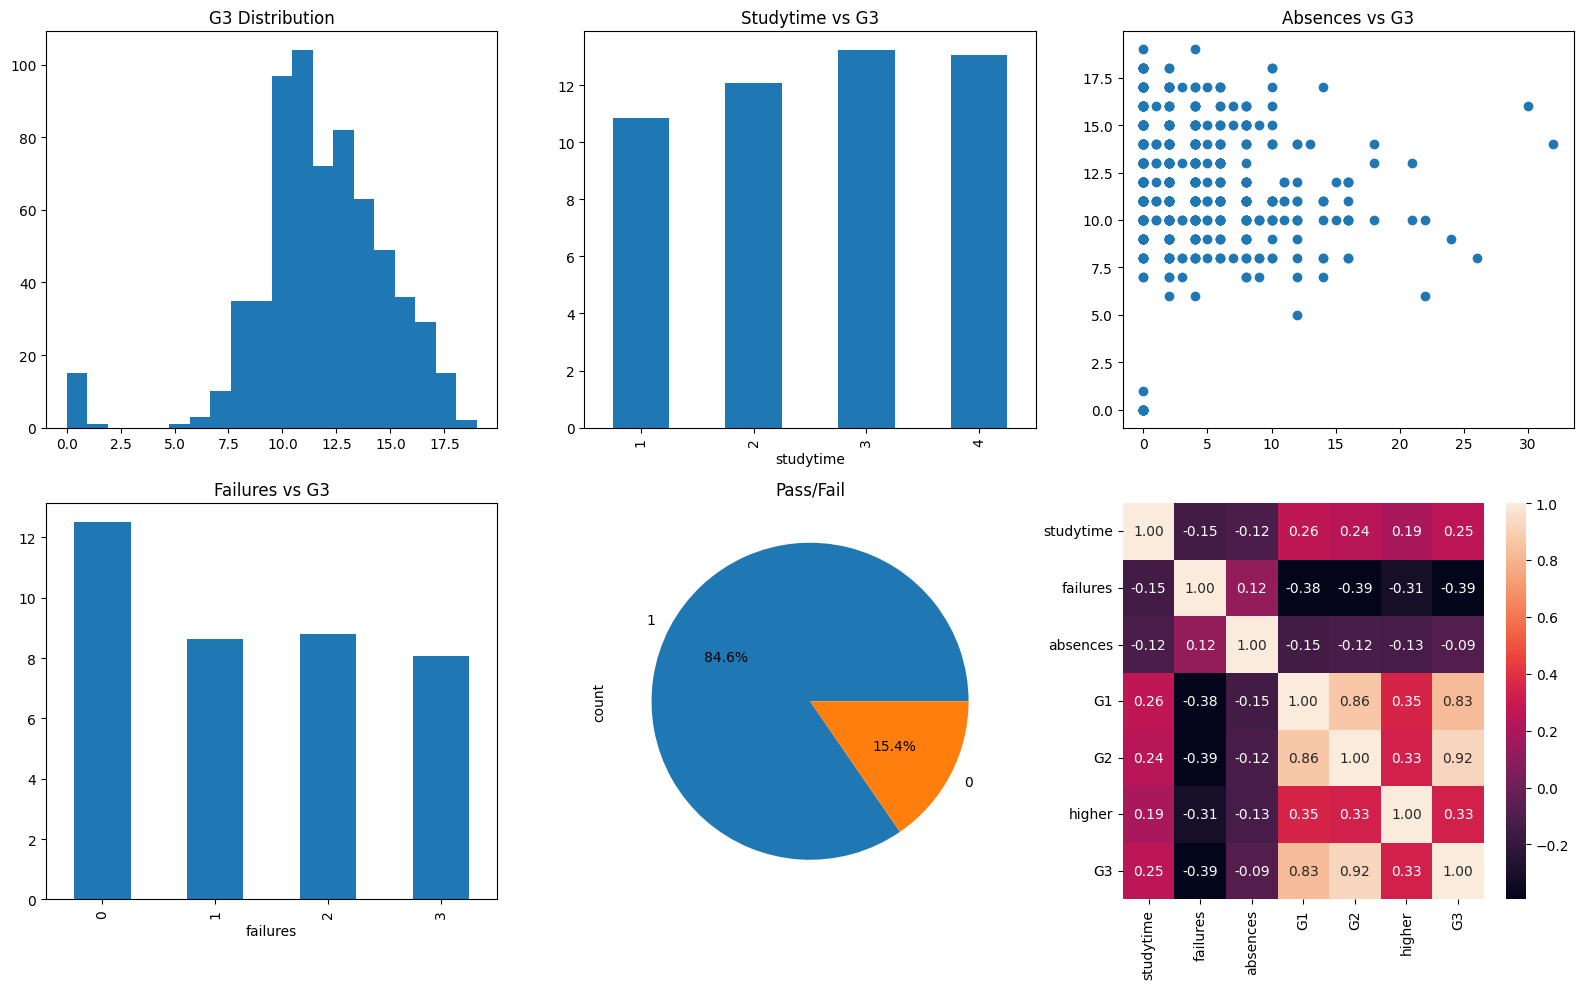


SECTION 5

Linear Regression
0.7314056906370676 1.3415422801744776 1.1582496622811844 0.8624301319449245

Logistic Regression
Accuracy: 0.9307692307692308
              precision    recall  f1-score   support

           0       0.69      0.73      0.71        15
           1       0.96      0.96      0.96       115

    accuracy                           0.93       130
   macro avg       0.83      0.84      0.84       130
weighted avg       0.93      0.93      0.93       130



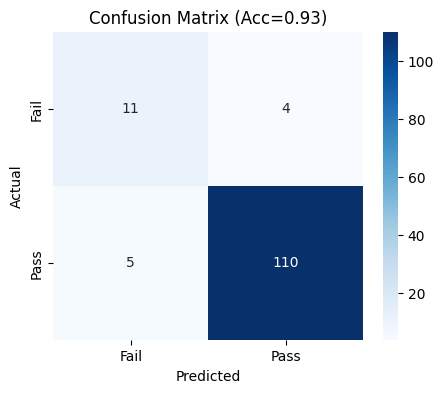


SECTION 6
P(Pass|High Study): 0.9318181818181818

SECTION 7


In [ ]:
# ============================================================
# Student Academic Performance Prediction
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    confusion_matrix, classification_report,
    accuracy_score
)
from sklearn.preprocessing import LabelEncoder


# ============================================================
# SECTION 1 — DATASET
# ============================================================
print("=" * 60)
print("SECTION 1: DATASET UNDERSTANDING")
print("=" * 60)

df = pd.read_csv("student-por.csv")

print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df.duplicated().sum())

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


# ============================================================
# SECTION 2 — PREPROCESSING
# ============================================================
print("\nSECTION 2")

df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

df.drop_duplicates(inplace=True)

le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded["Pass_Fail"] = (df_encoded["G3"] >= 10).astype(int)


# ============================================================
# SECTION 3 — FEATURE SELECTION
# ============================================================
print("\nSECTION 3")

EXCLUDE = ["G3", "school", "reason"]

features = [c for c in df_encoded.columns if c not in EXCLUDE + ["Pass_Fail"]]

corr = df_encoded[features + ["G3"]].corr()["G3"].drop("G3")
corr = corr.sort_values(key=abs, ascending=False)

REQUIRED = ["studytime", "failures", "absences", "G1", "G2"]

top_features = corr.head(10).index.tolist()
selected_features = list(dict.fromkeys(REQUIRED + top_features))

df_encoded["avg_prev_grade"] = (df_encoded["G1"] + df_encoded["G2"]) / 2
selected_features.append("avg_prev_grade")


# ============================================================
# SECTION 4 — EDA
# ============================================================
print("\nSECTION 4")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].hist(df["G3"], bins=20)
axes[0, 0].set_title("G3 Distribution")

df.groupby("studytime")["G3"].mean().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Studytime vs G3")

axes[0, 2].scatter(df["absences"], df["G3"])
axes[0, 2].set_title("Absences vs G3")

df.groupby("failures")["G3"].mean().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Failures vs G3")

df_encoded["Pass_Fail"].value_counts().plot(kind="pie", ax=axes[1, 1], autopct="%1.1f%%")
axes[1, 1].set_title("Pass/Fail")

sns.heatmap(df_encoded[selected_features[:6] + ["G3"]].corr(),
            ax=axes[1, 2], annot=True, fmt=".2f")

plt.tight_layout()
plt.show()


# ============================================================
# SECTION 5 — MACHINE LEARNING
# ============================================================
print("\nSECTION 5")

X = df_encoded[selected_features]
y_reg = df_encoded["G3"]
y_cls = df_encoded["Pass_Fail"]

X_train, X_test, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_c, y_test_c = train_test_split(X, y_cls, test_size=0.2, random_state=42)


# ---- Linear Regression ----
lr = LinearRegression()
lr.fit(X_train, y_train_r)
pred_r = lr.predict(X_test)

mae = mean_absolute_error(y_test_r, pred_r)
mse = mean_squared_error(y_test_r, pred_r)
rmse = np.sqrt(mse)
r2 = lr.score(X_test, y_test_r)

print("\nLinear Regression")
print(mae, mse, rmse, r2)


# ---- Logistic Regression ----
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train_c)
pred_c = log.predict(X_test)

acc = accuracy_score(y_test_c, pred_c)

print("\nLogistic Regression")
print("Accuracy:", acc)
print(classification_report(y_test_c, pred_c))


# ---- FIXED CONFUSION MATRIX ----
cm = confusion_matrix(y_test_c, pred_c)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",              # ✅ THIS FIXES YOUR ISSUE
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Acc={acc:.2f})")
plt.show()


# ============================================================
# SECTION 6 — BAYES
# ============================================================
print("\nSECTION 6")

high = df_encoded[df_encoded["studytime"] >= 3]
print("P(Pass|High Study):", high["Pass_Fail"].mean())


# ============================================================
# SECTION 7 — PREDICTION
# ============================================================
print("\nSECTION 7")

def predict_student():
    studytime = int(input("Studytime: "))
    failures = int(input("Failures: "))
    absences = int(input("Absences: "))
    G1 = float(input("G1: "))
    G2 = float(input("G2: "))

    avg = (G1 + G2) / 2

    base = df_encoded[selected_features].median().to_dict()
    base.update({
        "studytime": studytime,
        "failures": failures,
        "absences": absences,
        "G1": G1,
        "G2": G2,
        "avg_prev_grade": avg
    })

    input_df = pd.DataFrame([base])[selected_features]

    grade = lr.predict(input_df)[0]
    status = log.predict(input_df)[0]
    prob = log.predict_proba(input_df)[0][1]

    print("\nPredicted Grade:", round(grade, 2))
    print("Status:", "PASS" if status == 1 else "FAIL")
    print("Probability:", round(prob * 100, 2), "%")


predict_student()